# Observations:
- [ ] WFCRL paper doesn't produce do-nothing and random search baselines. For some of their experiments, their RL models are worse than naive baselines.
- [ ] They use two scenarios: Sc.1 and Sc. 2. The first one is fixes (options={"wind_speed": 8, "wind_direction": 270}) and is a challenging case with winds being perpendicular to the raws of turbins. The second one samples the initial conditions randomly, so ensembling is a must. 
- [ ] As a starting point: use Sc.1 on two farm layouts -- `Turb3_Row1_Floris` and `Ablaincourt_Floris`. Compare: do-nothing, random_search, GP, TabPFN, PFN4BO, GraphFPN, BNN, PPO.

In [11]:
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from wfcrl.rewards import StepPercentage
from wfcrl import environments as envs

from tabpfn import TabPFNRegressor
from tabpfn.constants import ModelVersion

import torch

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
SEED = 13
N_sim = 1000 # 100_000

In [2]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
device = 'cuda'

In [3]:
def step_policy(i):
    '''Randmoly samples actions'''
    joint_action = {"yaw": np.zeros(env.num_turbines)}
    mask = np.random.random(env.num_turbines) < 0.3 # proba of a turbine to get controled
    joint_action["yaw"][mask] = np.random.uniform(-5, 5, size=mask.sum())
    return joint_action

def obs_to_row(obs, reward, power, step):
    '''Writes all episode results into a dict'''
    row = {"step": step, "reward": reward[0]}
    for key, val in obs.items():
        val = np.atleast_1d(val)
        if len(val) == 1:
            row[key] = val[0]
        else:
            for i, v in enumerate(val):
                row[f"{key}_{i}"] = v
    for i in range(len(power)):
        row[f"power_{i}"] = power[i]
    return row

In [12]:
env = envs.make("Turb3_Row1_Floris", #"Ablaincourt_Floris",#
                max_num_steps=150,
                controls={"yaw": (-5, 5)},
                continuous_control = True, # continuous action space
                log=True)

In [13]:
sims, max_reward, rows = 0, -np.inf, []
while len(rows) < N_sim:
    observation = env.reset(seed=SEED, options={"wind_speed": 8, "wind_direction": 270}) # to fix initial coniditions (Sc.1): options={"wind_speed": 8, "wind_direction": 270}
    r, i = 0, 0
    done = False
    while not done:
        joint_action = step_policy(i)
        observation, reward, termination, truncation, info = env.step(joint_action)
        rows.append(obs_to_row(observation, reward, info["power"], i))  
        r += reward
        i += 1
        done = termination or truncation
    if sims%500==0:
        print(f"Simulation #{sims}: total reward = {r}")
    sims += 1 
    max_reward = max(max_reward, r)
print(f"Maximum total reward: {max_reward}")
sim_summary = pd.DataFrame(rows)
sim_summary

Simulation #0: total reward = [228.86295463]
Maximum total reward: [230.29565503]


,step,reward,yaw_0,yaw_1,yaw_2,freewind_measurements_0,freewind_measurements_1,wind_speed_0,wind_speed_1,wind_speed_2,wind_direction_0,wind_direction_1,wind_direction_2,power_0,power_1,power_2
0,0,1.528998,0.000000,0.000000,-1.000000,8.0,270.0,7.973633,4.896107,4.728997,270.264106,270.590438,270.421522,1.691327,0.362734,0.322553
1,1,1.528498,0.000000,-0.850562,0.000000,8.0,270.0,7.973633,4.896107,4.725708,270.264106,270.344114,270.554754,1.691327,0.362653,0.321873
2,2,1.528498,0.000000,-0.850562,0.000000,8.0,270.0,7.973633,4.896107,4.725708,270.264106,270.344114,270.554754,1.691327,0.362653,0.321873
3,3,1.528651,-0.827061,0.149438,0.000000,8.0,270.0,7.973633,4.897097,4.726739,270.144217,270.499388,270.647275,1.691015,0.362969,0.322120
4,4,1.529976,-0.408404,1.149438,-1.000000,8.0,270.0,7.973633,4.896138,4.736198,270.204903,270.856750,270.594226,1.691251,0.362593,0.324280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038,144,1.536856,-0.259086,4.000000,0.887772,8.0,270.0,7.973633,4.896023,4.787741,270.226550,271.698731,271.705812,1.691296,0.360921,0.336662
1039,145,1.540160,-0.259086,5.000000,0.887772,8.0,270.0,7.973633,4.896023,4.813515,270.226550,271.981166,271.883600,1.691296,0.359912,0.342842
1040,146,1.540160,-0.259086,5.000000,0.887772,8.0,270.0,7.973633,4.896023,4.813515,270.226550,271.981166,271.883600,1.691296,0.359912,0.342842
1041,147,1.540119,-0.259086,4.968294,0.026631,8.0,270.0,7.973633,4.896023,4.812642,270.226550,271.972259,271.627572,1.691296,0.359947,0.342719


In [6]:
from sklearn.datasets import fetch_openml
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [14]:
X = sim_summary[[f"yaw_{i}" for i in range(env.num_turbines)]+['freewind_measurements_0', 'freewind_measurements_1']]
y = sim_summary[[f'power_{i}' for i in range(env.num_turbines)]]

In [15]:
models = []
for i in range(3):
    regressor = TabPFNRegressor(random_state=SEED, device=device)
    regressor.fit(X, y[f'power_{i}'])
    models.append(regressor)

In [16]:
from scipy.optimize import minimize

def objective(yaws, models, freewind):
    X = np.concatenate([yaws, freewind]).reshape(1, -1)
    return -sum(m.predict(X)[0] for m in models)

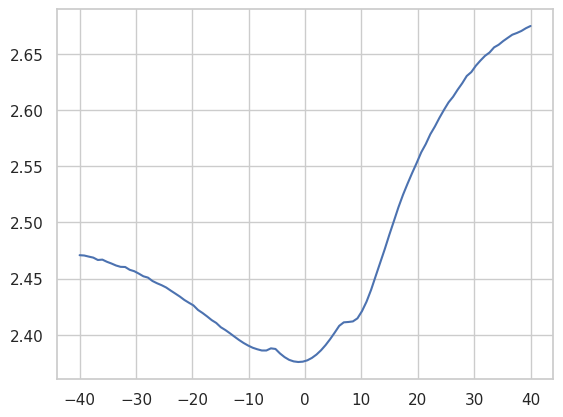

In [17]:
yaws_sweep = np.linspace(-40, 40, 100)
preds = []
for y in yaws_sweep:
    X_in = np.array([[y, 0, 0, 8.0, 270.0]])
    preds.append(sum(m.predict(X_in)[0] for m in models))
plt.plot(yaws_sweep, preds)

In [16]:
observation = env.reset(seed=SEED,options={"wind_speed": 8, "wind_direction": 270})
r, i, power = 0, 0, 0
done = False
while not done:

    freewind = torch.tensor(observation['freewind_measurements'], dtype=torch.double)
    current_yaw = observation['yaw']
    
    if i==0:
        result = minimize(
            objective, x0=current_yaw,
            args=(models, freewind),
            method="Nelder-Mead",#'L-BFGS-B',
            bounds=[(-5, 5)] * env.num_turbines,
            options={'maxiter': 40, 'ftol': 1e-4}
        )

    #if i == 0:
    joint_action = {'yaw': result['x'] - current_yaw}
    #else:
        #joint_action = {'yaw': np.zeros(env.num_turbines)}
        
    observation, reward, termination, truncation, info = env.step(joint_action)
    r += reward
    power += info["power"]
    i += 1
    done = termination or truncation
print(f"Total reward = {r}\tTotal power= {sum(power)}")

Total reward = [351.16638054]	Total power= 1271.6118774242086


In [18]:
joint_action

{'yaw': array([ 4.52639592e-11,  8.67450209e-13, -2.93722381e-12,  7.28547225e-12,
        -9.60980601e-12, -8.19204036e-12,  7.71880021e-12])}

In [15]:
obs, reward, _, _, info = env.step({'yaw': np.zeros(env.num_turbines)})
print(f"step reward: {reward}")
print(f"step power: {info.get('power', 'N/A')}")
print(f"step loads: {info.get('load', 'N/A')}")

step reward: [2.35682365]
step power: [1.69132665 0.39630197 1.68870792 1.3113222  1.30026544 1.20969173
 0.93669921]
step loads: [[0.06020304 0.2854754  0.09781062 0.0520248 ]
 [0.11336189 1.10848606 0.13966051 0.06096605]
 [0.06047356 0.28533935 0.10218463 0.04875879]
 [0.11098817 0.72576413 0.10929816 0.03985623]
 [0.11330846 0.70562934 0.10991932 0.03930753]
 [0.11342138 0.82187501 0.11171011 0.03783295]
 [0.11431011 1.11026893 0.11963405 0.03487882]]


In [13]:
obs = env.reset(options={"wind_speed": 8, "wind_direction": 270})
r = 0
for _ in range(150):
    obs, reward, _, _, info = env.step({'yaw': np.zeros(env.num_turbines)})
    r += reward
print(f"Do-nothing total: {r}")

Do-nothing total: [353.523547]


In [100]:
from wfcrl.environments import data_cases as cases
print(cases.floris_ablaincourt)

Wind farm simulation on Floris: 7 turbines - 150 timesteps
xcoords: [484.8, 797.1, 1038.8, 1377.6, 1716.9, 2057.3, 2400.0]
ycoords: [274.0, 251.0, 66.9, -22.7, -112.5, -195.3, -259.0]
direction: 270
speed: 8
wind_time_series: None



In [114]:
print(dec_env.action_space(dec_env.agents[0]))

{'yaw': Box(-1.0, 1.0, (1,), float32)}
